In [1]:
from eyened_orm import ImageInstance,  Database
from sqlalchemy import select, func
from random import sample
from eyened_orm.importer.thumbnails import get_thumbnail

In [2]:
database = Database('../../environments/prod_wr.env')
session = database.create_session()

loading from .env file ../../environments/prod_wr.env


In [3]:
images = session.scalars(select(ImageInstance).order_by(func.random()).limit(2000)).all()

In [4]:
images_binary = [im for im in images if im.path.suffix == ".binary"]
images_dicom = [im for im in images if im.path.suffix == ".dcm"]
images_png = [im for im in images if im.path.suffix == ".png"]

In [5]:
def plot(ims_sample):
    import numpy as np

    import matplotlib.pyplot as plt
    
    fig, axs = plt.subplots(2, 4, figsize=(15, 8))
    axs = axs.flatten()

    for i, (im) in enumerate(ims_sample):
        print(im.ImageInstanceID, im.path)
        img = get_thumbnail(im)
        if img is not None:
            if img.ndim == 3:
                axs[i].imshow(img)
            else:
                axs[i].imshow(img, cmap="gray")
            
        axs[i].set_title(f"ID: {im.ImageInstanceID}")
        axs[i].axis('off')

    plt.tight_layout()
    plt.show()

1112231 /mnt/oogergo/ergo/HRA_ERGO/DATA/2877a088-aa44-4742-9c7f-7751c8a2faac/00007702-00063618-AF_B-0-5.png
368806 /mnt/oogergo/ergo/OCT_ERGO/OCT_prd/4e69fdc9-5d76-454a-a2b4-aeedd3d2c114/64984.png
606306 /mnt/oogergo/ergo/CF_ERGO/DATA_IBASE/5acc4d94-392e-407c-ae2f-2ee1196a49f2/2TNVH5GI31YFEJ0K.png
820044 /mnt/oogergo/ergo/CF_ERGO/DATA_IBASE/6c7e821b-a038-4b83-9a51-5c9740beb344/4568V16B6TI1IVBH.png
2277872 /mnt/oogergo/eyened/uitwissel/areds/imgs/extracted/AREDS_AREDS_2010_dng_Fundus_Field_3_Baseline_AMD_Category_1_Final_AMD_Phenotype_Control_Control_Year10/1939_20_LE_F3M.png
769761 /mnt/oogergo/ergo/CF_ERGO/DATA_IBASE/19b8da12-c46d-4fad-bbeb-cf6baf38882e/4568V16B456EJ0XQ.png
2470530 /mnt/oogergo/eyened/uitwissel/areds/imgs/extracted/AREDS_AREDS_2010_dng_Fundus_FundusReflex_Baseline_AMD_Category_4a_Final_AMD_Phenotype_Case_NV_AMD_Year10/2974_20_LE_FunRef_LS.png
691729 /mnt/oogergo/ergo/CF_ERGO/DATA_IBASE/b50b5a81-38e3-4a9c-819a-efd7fa2047db/4568V16B6XQS5KZX.png


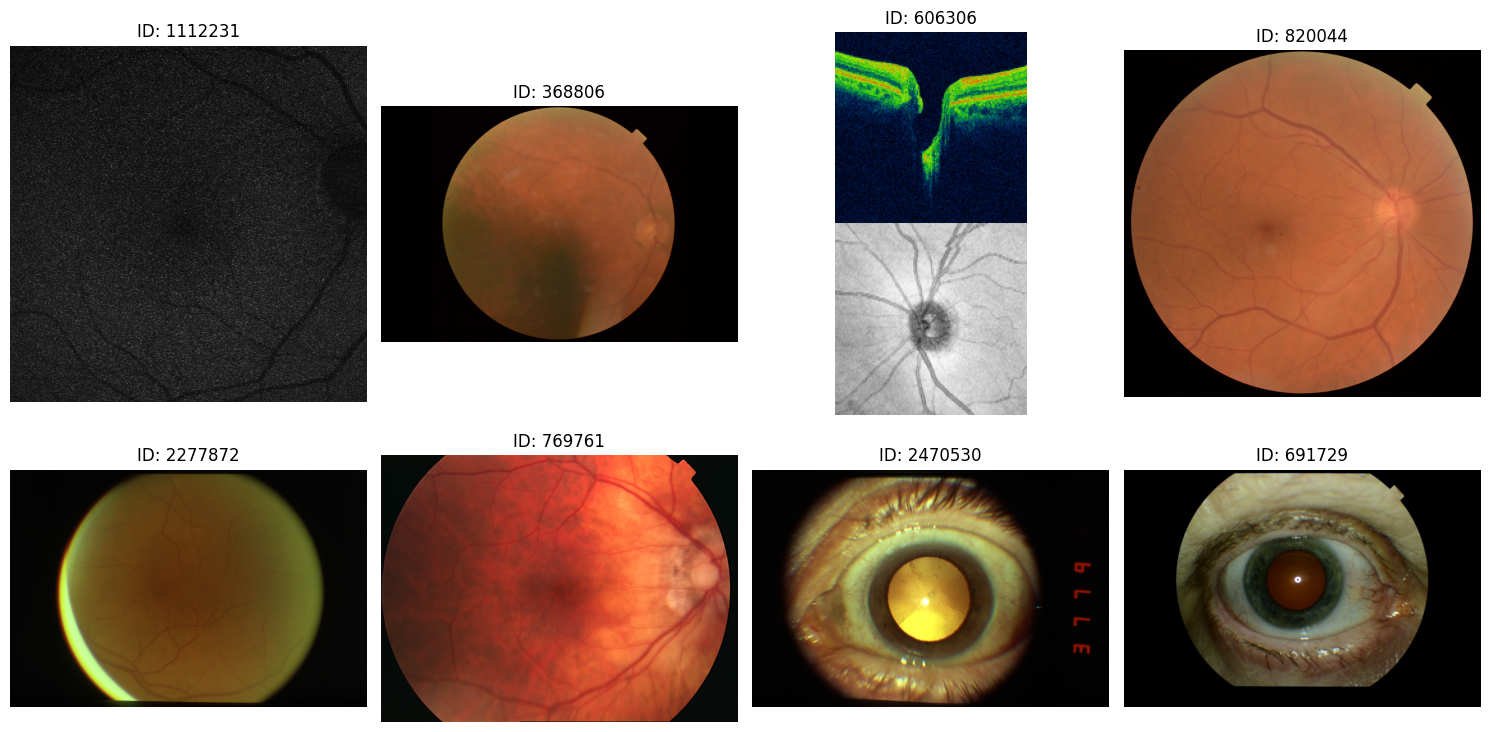

In [6]:
ims_sample = sample(images_png, 8)
plot(ims_sample)

2527441 /mnt/oogergo/ergo/TRITON_ERGO/dicom/StudyInstance_1.2.392.200106.1651.6.2.10488921131229.45852.43348/SC.1.2.392.200106.1651.6.2.10488921131229.3961746077.398.dcm
2125862 /mnt/oogergo/ergo/TRITON_ERGO/dicom/StudyInstance_1.2.392.200106.1651.6.2.1048892848179.45143.21446/OPt.1.2.392.200106.1651.6.2.1048892848179.3900489301.186.dcm
2190018 /mnt/oogergo/ergo/TRITON_ERGO/dicom/StudyInstance_1.2.392.200106.1651.6.2.1048892848179.45187.21571/OPb.1.2.392.200106.1651.6.2.1048892848179.3904277595.55.dcm
2197323 /mnt/oogergo/ergo/TRITON_ERGO/dicom/StudyInstance_1.2.392.200106.1651.6.2.1048892848179.45221.21673/SC.1.2.392.200106.1651.6.2.1048892848179.3907212768.46.dcm
1552022 /mnt/oogergo/ergo/TRITON_ERGO/dicom/StudyInstance_1.2.392.200106.1651.6.2.1048892848179.45059.11230/SC.1.2.392.200106.1651.6.2.1048892848179.3893217743.92.dcm
2236839 /mnt/oogergo/ergo/TRITON_ERGO/dicom/StudyInstance_1.2.392.200106.1651.6.2.1048892848179.45564.22528/OPb.1.2.392.200106.1651.6.2.1048892848179.391655221

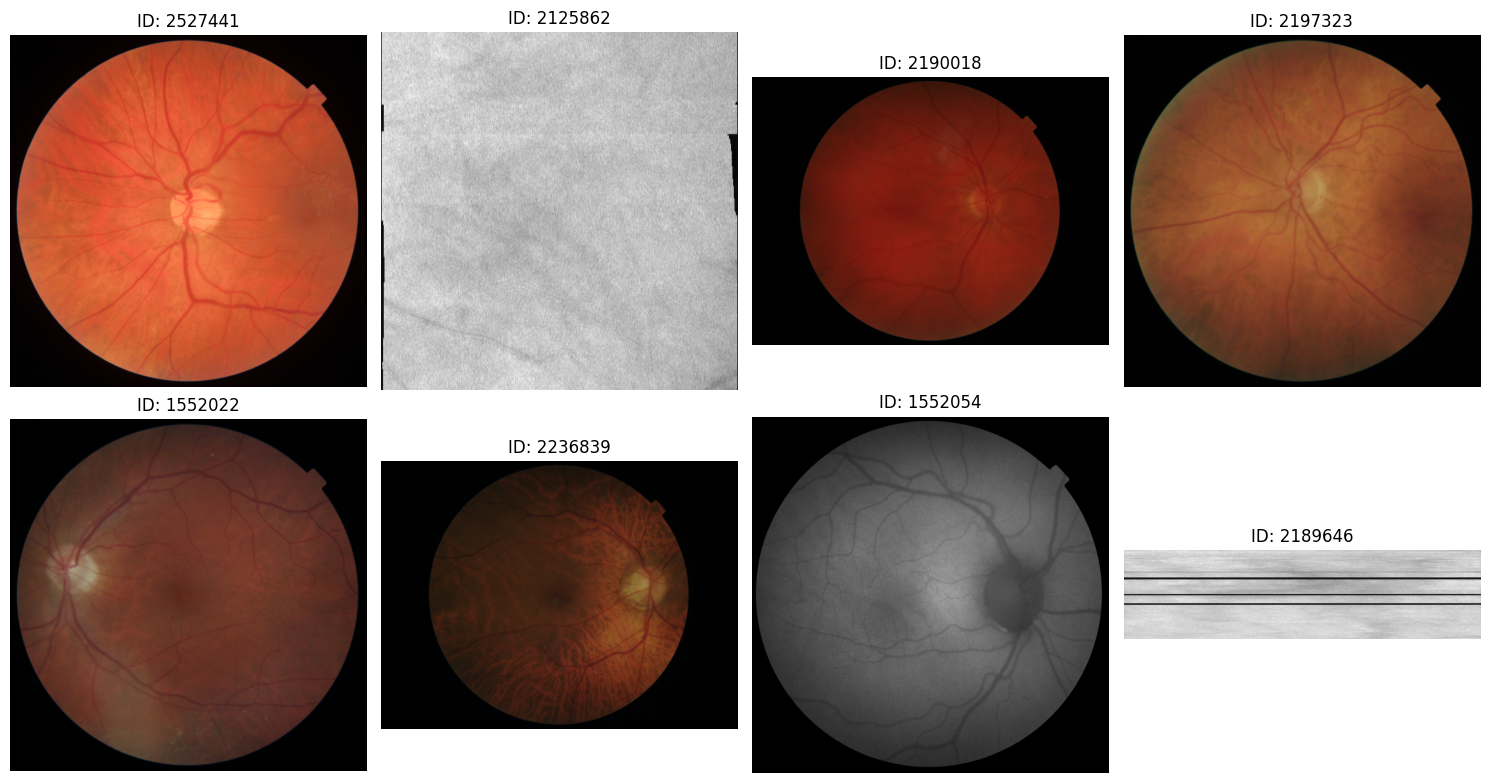

In [7]:
ims_sample = sample(images_dicom, 8)
plot(ims_sample)

370136 /mnt/oogergo/ergo/OCT_ERGO/OCT_prd/fefdbfae-f1d0-4eac-b4c2-84e90a1f7d79/65432.binary
241607 /mnt/oogergo/ergo/OCT_ERGO/OCT_prd/8a0402c0-baa7-4841-9f3a-4b65aec607e2/20134.binary
195271 /mnt/oogergo/ergo/OCT_ERGO/OCT_prd/065260d5-10db-4669-98d6-ffe83ffe8797/900.binary
363353 /mnt/oogergo/ergo/OCT_ERGO/OCT_prd/05e3204e-e18d-4403-a852-79ae42696af3/63113.binary
300656 /mnt/oogergo/ergo/OCT_ERGO/OCT_prd/2bca387a-4de8-43ce-a1f0-040abeda404f/39819.binary
253232 /mnt/oogergo/ergo/OCT_ERGO/OCT_prd/8a18ac9a-9c15-4d51-a864-db7ea6a26be7/24009.binary
249464 /mnt/oogergo/ergo/OCT_ERGO/OCT_prd/519693c1-a881-40e3-9a75-ecf10ed498da/22753.binary
289109 /mnt/oogergo/ergo/OCT_ERGO/OCT_prd/82b35f71-f223-48fe-ab56-0a42c43c31bf/35970.binary


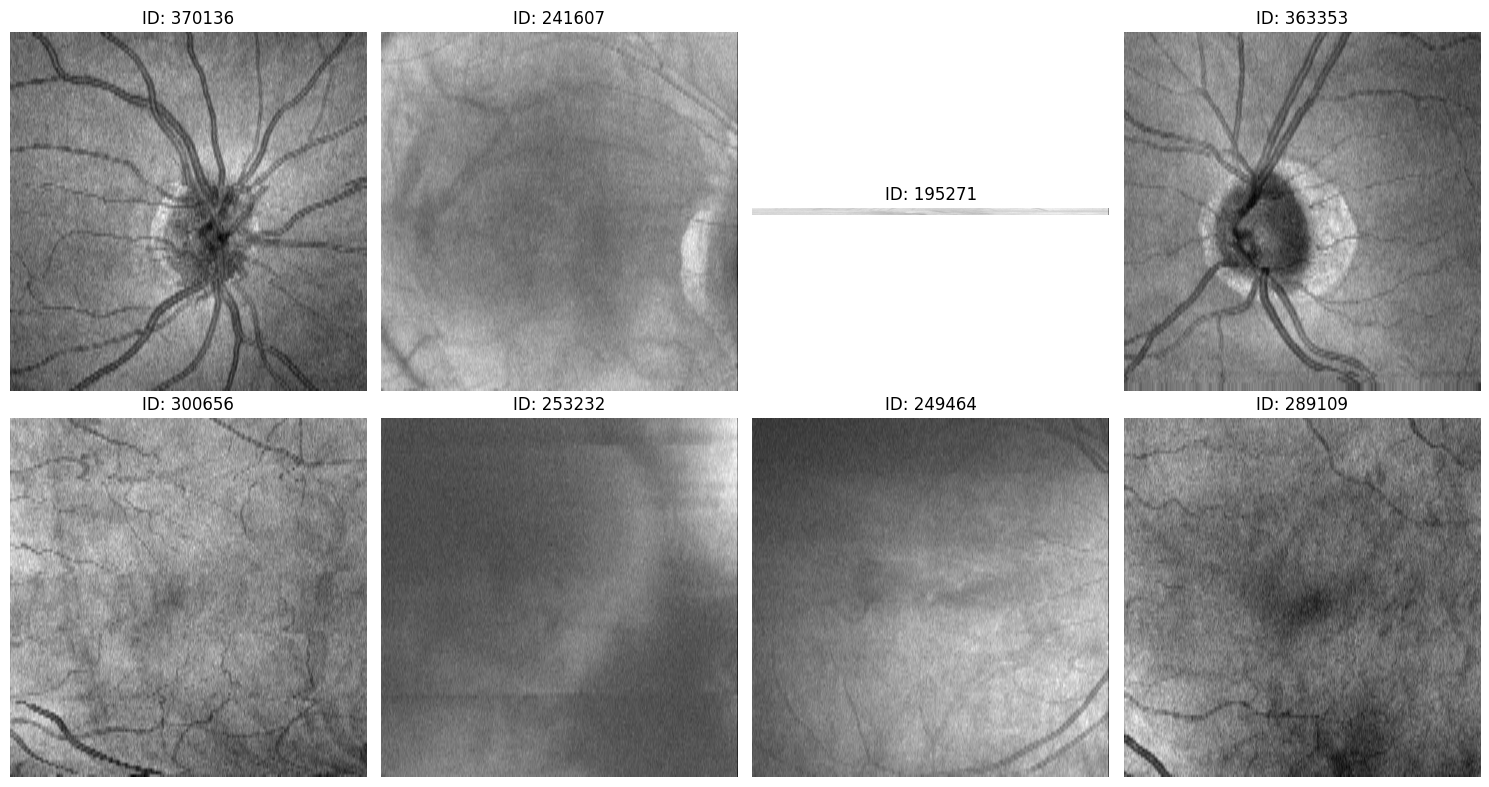

In [8]:
ims_sample = sample(images_binary, 8)
plot(ims_sample)